In [120]:
import requests
import pandas as pd
import geopandas as gpd
import folium

In [121]:
url = "https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/all_day.geojson"

responses = requests.get(url)
data = responses.json()


In [122]:
responses

<Response [200]>

In [123]:
print(data.keys())
len(data['features'])
data['features'][0]

dict_keys(['type', 'metadata', 'features', 'bbox'])


{'type': 'Feature',
 'properties': {'mag': 2.3,
  'place': '57 km SE of Cantwell, Alaska',
  'time': 1782030731208,
  'updated': 1782030872981,
  'tz': None,
  'url': 'https://earthquake.usgs.gov/earthquakes/eventpage/aka2026memveh',
  'detail': 'https://earthquake.usgs.gov/earthquakes/feed/v1.0/detail/aka2026memveh.geojson',
  'felt': None,
  'cdi': None,
  'mmi': None,
  'alert': None,
  'status': 'automatic',
  'tsunami': 0,
  'sig': 81,
  'net': 'ak',
  'code': 'a2026memveh',
  'ids': ',aka2026memveh,',
  'sources': ',ak,',
  'types': ',origin,phase-data,',
  'nst': 86,
  'dmin': 0.5,
  'rms': 1.4,
  'gap': 20,
  'magType': 'ml',
  'type': 'earthquake',
  'title': 'M 2.3 - 57 km SE of Cantwell, Alaska'},
 'geometry': {'type': 'Point', 'coordinates': [-148.278, 62.971, 5]},
 'id': 'aka2026memveh'}

In [124]:
earthquakes = []


for feature in data['features']:
    mag = feature['properties']['mag']
    place = feature['properties']['place']
    time =pd.to_datetime(
        feature['properties']['time'],
        unit='ms'
    )
    coords = feature['geometry']['coordinates']
    longitude = coords[0]
    latitude = coords[1]
    depth = coords[2]
    earthquakes.append({
    "mag": mag,
    "place": place,
    "time": time,
    "longitude": longitude,
    "latitude": latitude,
    "depth": depth
})



In [125]:
len(earthquakes)

219

In [126]:
df = pd.DataFrame(earthquakes)

df.head()


,mag,place,time,longitude,latitude,depth
0,2.30,"57 km SE of Cantwell, Alaska",2026-06-21 08:32:11.208,-148.278000,62.971000,5.00
1,4.20,western Xizang,2026-06-21 07:50:40.804,81.346800,33.491100,10.00
2,1.37,"14 km S of Anza, CA",2026-06-21 07:43:59.420,-116.649000,33.434833,6.04
3,2.38,"44 km W of Petrolia, CA",2026-06-21 07:34:25.380,-124.794167,40.398998,7.53
4,1.31,"4 km E of Ojai, CA",2026-06-21 07:30:41.540,-119.198667,34.449500,10.68


In [127]:
df.shape

(219, 6)

In [128]:
from shapely.geometry import Point 

df['geometry'] = df.apply(
    lambda row: Point(row['longitude'],row['latitude']
                    ),axis=1
)

In [129]:
df['geometry'].head()

0                      POINT (-148.278 62.971)
1                      POINT (81.3468 33.4911)
2            POINT (-116.649 33.4348333333333)
3    POINT (-124.794166564941 40.398998260498)
4            POINT (-119.198666666667 34.4495)
Name: geometry, dtype: object

In [130]:
gdf = gpd.GeoDataFrame(
    df,
    geometry = 'geometry',
    crs = 'EPSG:4326'
)

gpd.GeoDataFrame(df)

,mag,place,time,longitude,latitude,depth,geometry
0,2.30,"57 km SE of Cantwell, Alaska",2026-06-21 08:32:11.208,-148.278000,62.971000,5.000000,POINT (-148.28 62.971)
1,4.20,western Xizang,2026-06-21 07:50:40.804,81.346800,33.491100,10.000000,POINT (81.347 33.491)
2,1.37,"14 km S of Anza, CA",2026-06-21 07:43:59.420,-116.649000,33.434833,6.040000,POINT (-116.65 33.435)
3,2.38,"44 km W of Petrolia, CA",2026-06-21 07:34:25.380,-124.794167,40.398998,7.530000,POINT (-124.79 40.399)
4,1.31,"4 km E of Ojai, CA",2026-06-21 07:30:41.540,-119.198667,34.449500,10.680000,POINT (-119.2 34.45)
...,...,...,...,...,...,...,...
214,1.70,"12 km SSE of Fern Forest, Hawaii",2026-06-20 09:02:09.120,-155.102829,19.358000,31.219999,POINT (-155.1 19.358)
215,-0.23,"65 km WNW of Beluga, Alaska",2026-06-20 09:00:32.320,-152.232000,61.328667,3.290000,POINT (-152.23 61.329)
216,2.02,"21 km ESE of Naalehu, Hawaii",2026-06-20 08:58:03.190,-155.383667,19.029667,29.090000,POINT (-155.38 19.03)
217,2.00,"31 km WSW of Nanwalek, Alaska",2026-06-20 08:54:03.523,-152.387000,59.199000,62.800000,POINT (-152.39 59.199)


In [131]:
type(gdf)

geopandas.geodataframe.GeoDataFrame

In [132]:

gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

<Axes: >

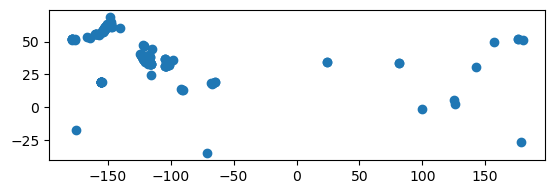

In [133]:
gdf.plot()

In [134]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 219 entries, 0 to 218
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   mag        218 non-null    float64       
 1   place      219 non-null    object        
 2   time       219 non-null    datetime64[ns]
 3   longitude  219 non-null    float64       
 4   latitude   219 non-null    float64       
 5   depth      219 non-null    float64       
 6   geometry   219 non-null    geometry      
dtypes: datetime64[ns](1), float64(4), geometry(1), object(1)
memory usage: 12.1+ KB


In [135]:
print("Total Earthquakes:", len(gdf))
print("Strongest Magnitude:", gdf["mag"].max())
print("Average Magnitude:", gdf["mag"].mean())
print("Deepest Earthquake:", gdf["depth"].max())

Total Earthquakes: 219
Strongest Magnitude: 5.2
Average Magnitude: 1.6570528259528539
Deepest Earthquake: 605.553


In [136]:
weak_eq = gdf[gdf['mag']<4]
weak_eq

,mag,place,time,longitude,latitude,depth,geometry
0,2.30,"57 km SE of Cantwell, Alaska",2026-06-21 08:32:11.208,-148.278000,62.971000,5.000000,POINT (-148.28 62.971)
2,1.37,"14 km S of Anza, CA",2026-06-21 07:43:59.420,-116.649000,33.434833,6.040000,POINT (-116.65 33.435)
3,2.38,"44 km W of Petrolia, CA",2026-06-21 07:34:25.380,-124.794167,40.398998,7.530000,POINT (-124.79 40.399)
4,1.31,"4 km E of Ojai, CA",2026-06-21 07:30:41.540,-119.198667,34.449500,10.680000,POINT (-119.2 34.45)
5,0.93,"11 km WNW of Cobb, CA",2026-06-21 07:30:01.830,-122.847504,38.850498,1.350000,POINT (-122.85 38.85)
...,...,...,...,...,...,...,...
214,1.70,"12 km SSE of Fern Forest, Hawaii",2026-06-20 09:02:09.120,-155.102829,19.358000,31.219999,POINT (-155.1 19.358)
215,-0.23,"65 km WNW of Beluga, Alaska",2026-06-20 09:00:32.320,-152.232000,61.328667,3.290000,POINT (-152.23 61.329)
216,2.02,"21 km ESE of Naalehu, Hawaii",2026-06-20 08:58:03.190,-155.383667,19.029667,29.090000,POINT (-155.38 19.03)
217,2.00,"31 km WSW of Nanwalek, Alaska",2026-06-20 08:54:03.523,-152.387000,59.199000,62.800000,POINT (-152.39 59.199)


In [137]:
total_eq = len(gdf)

strongest_mag = gdf["mag"].max()

latest_time = gdf["time"].max()

avg_mag = round(gdf["mag"].mean(), 2)

strongest_place = gdf.loc[gdf["mag"].idxmax(), "place"]
deepest_eq = gdf['depth'].max()

print("Total Earthquakes:", total_eq)
print("Strongest Magnitude:", strongest_mag)
print("Strongest Location:", strongest_place)
print("Latest Earthquake:", latest_time)
print("Average Magnitude:", avg_mag)
print("Deepest Earthquake:", deepest_eq)

Total Earthquakes: 219
Strongest Magnitude: 5.2
Strongest Location: 10 km S of Kastrí, Greece
Latest Earthquake: 2026-06-21 08:32:11.208000
Average Magnitude: 1.66
Deepest Earthquake: 605.553


In [138]:

top10 = gdf.sort_values(
    "mag",
    ascending=False
)

top10[[
    "mag",
    "place",
    "depth"
]].head(10)

,mag,place,depth
207,5.2,"10 km S of Kastrí, Greece",10.000
208,4.9,"20 km SE of Kastrí, Greece",10.000
22,4.8,south of the Fiji Islands,605.553
146,4.8,"172 km SW of Hihifo, Tonga",272.579
87,4.7,"115 km SE of Severo-Kuril’sk, Russia",35.000
45,4.7,"80 km WSW of Padang, Indonesia",52.911
16,4.6,"Off the coast of Baja California Sur, Mexico",10.000
173,4.5,"Izu Islands, Japan region",15.983
168,4.5,"13 km SSW of Balangonan, Philippines",61.931
20,4.4,"106 km NNE of Bitung, Indonesia",132.746


In [139]:
strongest_eq = gdf.loc[gdf['mag'].idxmax()]

strongest_eq

mag                                 5.2
place         10 km S of Kastrí, Greece
time         2026-06-20 09:37:24.290000
longitude                       24.0997
latitude                        34.7437
depth                              10.0
geometry        POINT (24.0997 34.7437)
Name: 207, dtype: object

In [140]:
lat = strongest_eq['latitude']
lon = strongest_eq['longitude']
mag = strongest_eq['mag']
place = strongest_eq['place']

In [141]:
m = folium.Map(
    location =[0,0],
    zoom_start = 2
)

folium.Marker(
    location = [lat,lon],
    popup=f"{place} | M {mag}"
).add_to(m)

m

In [142]:
from folium.plugins import MarkerCluster



m = folium.Map(
    location=[0, 0],
    zoom_start=2
)
marker_cluster = MarkerCluster().add_to(m)

for index, row in gdf.iterrows():
    mag = row["mag"]
    if mag < 2:
     color = "green"
    elif mag < 4:
     color = "orange"
    else:
     color = "red"

    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius = mag*2,
        popup=f'{row["place"]} | M {mag}',
        color = color,
        fill = True ,
        fill_color = color
        
    ).add_to(marker_cluster)

m

In [143]:
m.save("earthquake_dashboard.html")

print("Successful")


Successful


In [144]:
import streamlit as st

print("Streamlit Installed")

Streamlit Installed


In [145]:
type(gdf)

geopandas.geodataframe.GeoDataFrame

In [146]:
world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)

print(world.shape)
print(world.columns)

(177, 169)
Index(['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3',
       'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN',
       ...
       'FCLASS_TR', 'FCLASS_ID', 'FCLASS_PL', 'FCLASS_GR', 'FCLASS_IT',
       'FCLASS_NL', 'FCLASS_SE', 'FCLASS_BD', 'FCLASS_UA', 'geometry'],
      dtype='object', length=169)


In [147]:
world[["ADMIN", "CONTINENT", "geometry"]].head()



,ADMIN,CONTINENT,geometry
0,Fiji,Oceania,"MULTIPOLYGON (((180 -16.067, 180 -16.555, 179...."
1,United Republic of Tanzania,Africa,"POLYGON ((33.904 -0.95, 34.073 -1.0598, 37.699..."
2,Western Sahara,Africa,"POLYGON ((-8.6656 27.656, -8.6651 27.589, -8.6..."
3,Canada,North America,"MULTIPOLYGON (((-122.84 49, -122.97 49.003, -1..."
4,United States of America,North America,"MULTIPOLYGON (((-122.84 49, -120 49, -117.03 4..."


In [148]:
print(world.crs)
print(gdf.crs)


EPSG:4326
EPSG:4326


In [149]:
eq_country = gpd.sjoin(
    gdf,
    world[["ADMIN", "geometry"]],
    how="left",
    predicate="within"
)

In [150]:
eq_country[["place", "ADMIN"]].head(10)

,place,ADMIN
0,"57 km SE of Cantwell, Alaska",United States of America
1,western Xizang,China
2,"14 km S of Anza, CA",United States of America
3,"44 km W of Petrolia, CA",NaN
4,"4 km E of Ojai, CA",United States of America
5,"11 km WNW of Cobb, CA",United States of America
6,"4 km E of Ojai, CA",United States of America
7,"4 km NE of Ojai, CA",United States of America
8,"14 km ENE of Julian, CA",United States of America
9,"8 km WNW of Tahoe Vista, CA",United States of America


In [151]:
eq_country["ADMIN"].value_counts().head(10)

ADMIN
United States of America    165
China                         2
Puerto Rico                   1
Chile                         1
Name: count, dtype: int64

In [152]:
eq_country[eq_country["ADMIN"].isna()][
    ["place", "mag"]
].head(20)

,place,mag
3,"44 km W of Petrolia, CA",2.38
14,"28 km NNE of Aleneva, Alaska",1.50
16,"Off the coast of Baja California Sur, Mexico",4.60
17,"60 km SSW of Puerto San José, Guatemala",4.30
18,"13 km S of Carmel By The Sea, CA",2.24
20,"106 km NNE of Bitung, Indonesia",4.40
22,south of the Fiji Islands,4.80
45,"80 km WSW of Padang, Indonesia",4.70
60,"24 km WNW of Clam Gulch, Alaska",2.40
66,"26 km WNW of Clam Gulch, Alaska",1.40


<Axes: >

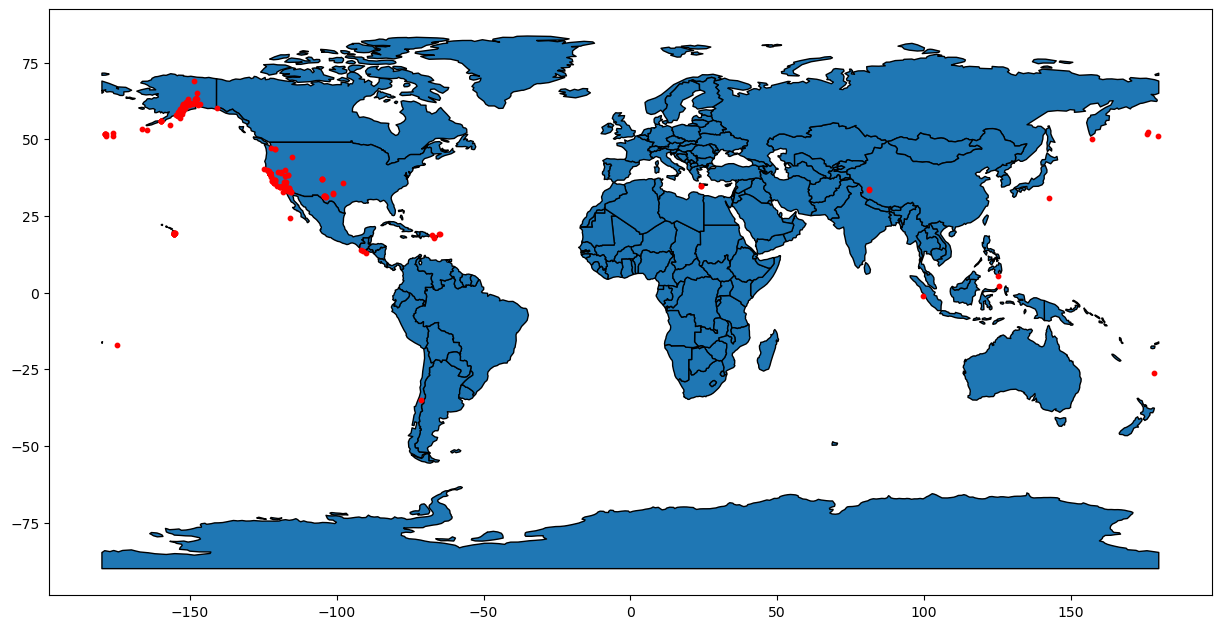

In [153]:
ax = world.plot(
    figsize=(15,8),
    edgecolor="black"
)

gdf.plot(
    ax=ax,
    color="red",
    markersize=10
)



In [154]:
strong_eq = gdf[gdf['mag']>=4]

strong_eq_proj = strong_eq.to_crs(3857)

print(strong_eq_proj.crs)

EPSG:3857


In [155]:
strong_eq_proj['buffer'] = strong_eq_proj.buffer(500000)
strong_eq_proj[['mag','buffer']].head()

,mag,buffer
1,4.2,"POLYGON ((9.56e+06 3.96e+06, 9.55e+06 3.91e+06..."
16,4.6,"POLYGON ((-1.24e+07 2.78e+06, -1.24e+07 2.73e+..."
17,4.3,"POLYGON ((-9.64e+06 1.51e+06, -9.64e+06 1.46e+..."
20,4.4,"POLYGON ((1.45e+07 2.52e+05, 1.45e+07 2.03e+05..."
22,4.8,"POLYGON ((2.03e+07 -3.04e+06, 2.03e+07 -3.09e+..."


<Axes: >

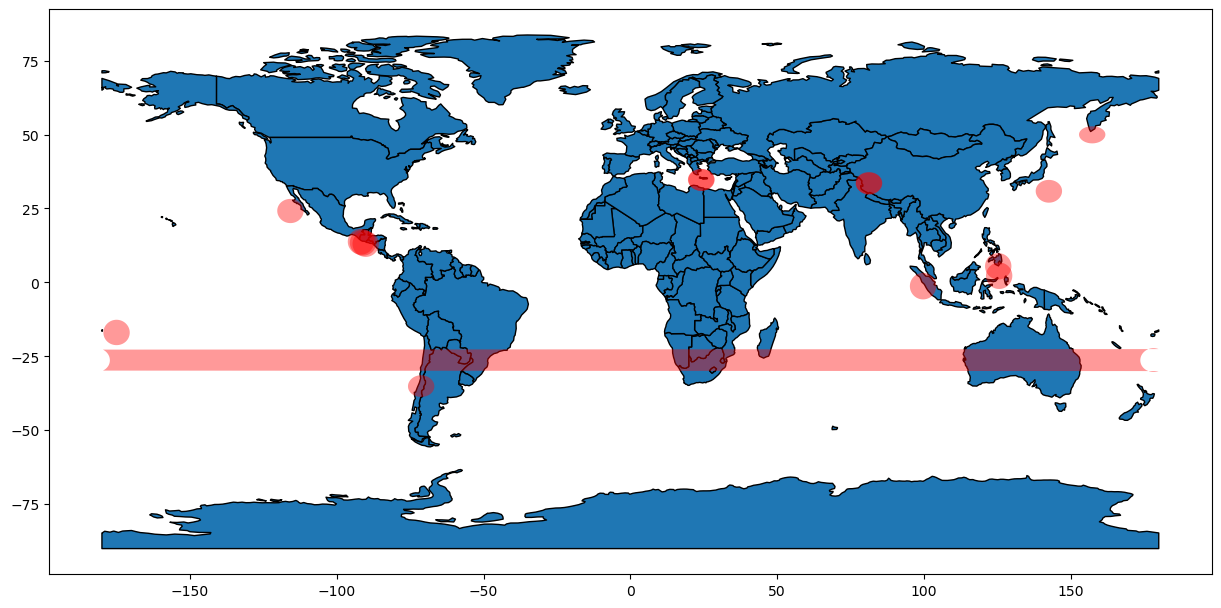

In [156]:
buffer_gdf = strong_eq_proj.set_geometry("buffer")
buffer_gdf = buffer_gdf.to_crs(4326)
ax = world.plot(
    figsize=(15,8),
    edgecolor="black"
)

buffer_gdf.plot(
    ax=ax,
    alpha=0.4,
    color="red"
)

In [157]:
delhi = Point(77.21, 28.61)

delhi_gdf = gpd.GeoDataFrame(
    {"city": ["Delhi"]},
    geometry=[delhi],
    crs="EPSG:4326"
)

gdf_proj = gdf.to_crs(3857)

delhi_proj = delhi_gdf.to_crs(3857)

delhi_point = delhi_proj.geometry.iloc[0]

gdf_proj["distance_m"] = gdf_proj.distance(delhi_point)

nearest_eq = gdf_proj.sort_values(
    "distance_m"
).iloc[0]

nearest_eq[
    ["place", "mag", "distance_m"]
]

place         western Xizang
mag                      4.2
distance_m     784058.056081
Name: 1, dtype: object

In [158]:
nearest_eq["distance_m"] / 1000

784.0580560813205

In [159]:
nearest_eq

mag                                                   4.2
place                                      western Xizang
time                           2026-06-21 07:50:40.804000
longitude                                         81.3468
latitude                                          33.4911
depth                                                10.0
geometry      POINT (9055484.353662267 3960672.174048917)
distance_m                                  784058.056081
Name: 1, dtype: object

In [160]:
nearest_5 = gdf_proj.sort_values(
    "distance_m"
).head(5)

nearest_5[
    ["place", "mag", "distance_m"]
]

,place,mag,distance_m
1,western Xizang,4.2,7.840581e+05
50,western Xizang,4.3,7.930123e+05
45,"80 km WSW of Padang, Indonesia",4.7,4.277715e+06
208,"20 km SE of Kastrí, Greece",4.9,5.951187e+06
207,"10 km S of Kastrí, Greece",5.2,5.966495e+06


In [161]:
nearest_5["distance_km"] = (
    nearest_5["distance_m"] / 1000
)
nearest_5[
    ["place", "mag", "distance_km"]
]

,place,mag,distance_km
1,western Xizang,4.2,784.058056
50,western Xizang,4.3,793.012264
45,"80 km WSW of Padang, Indonesia",4.7,4277.714786
208,"20 km SE of Kastrí, Greece",4.9,5951.186653
207,"10 km S of Kastrí, Greece",5.2,5966.494925


In [162]:
nearest_5[[
    "place",
    "longitude",
    "latitude",
    "distance_km"
]]

,place,longitude,latitude,distance_km
1,western Xizang,81.3468,33.4911,784.058056
50,western Xizang,81.2209,33.6468,793.012264
45,"80 km WSW of Padang, Indonesia",99.7076,-1.2742,4277.714786
208,"20 km SE of Kastrí, Greece",24.2303,34.6941,5951.186653
207,"10 km S of Kastrí, Greece",24.0997,34.7437,5966.494925


In [165]:
country_counts = (
    eq_country["ADMIN"]
    .value_counts()
    .reset_index()
)
country_counts.head()

,ADMIN,count
0,United States of America,165
1,China,2
2,Puerto Rico,1
3,Chile,1


In [166]:
country_counts.columns

Index(['ADMIN', 'count'], dtype='object')

In [168]:
world_eq = world.merge(
    country_counts,
    on="ADMIN",
    how="left"
)
world_eq[["ADMIN", "count"]].head()

,ADMIN,count
0,Fiji,NaN
1,United Republic of Tanzania,NaN
2,Western Sahara,NaN
3,Canada,NaN
4,United States of America,165.0


In [170]:
world_eq["count"] = world_eq["count"].fillna(0)
world_eq[["ADMIN", "count"]].head()

,ADMIN,count
0,Fiji,0.0
1,United Republic of Tanzania,0.0
2,Western Sahara,0.0
3,Canada,0.0
4,United States of America,165.0


<Axes: >

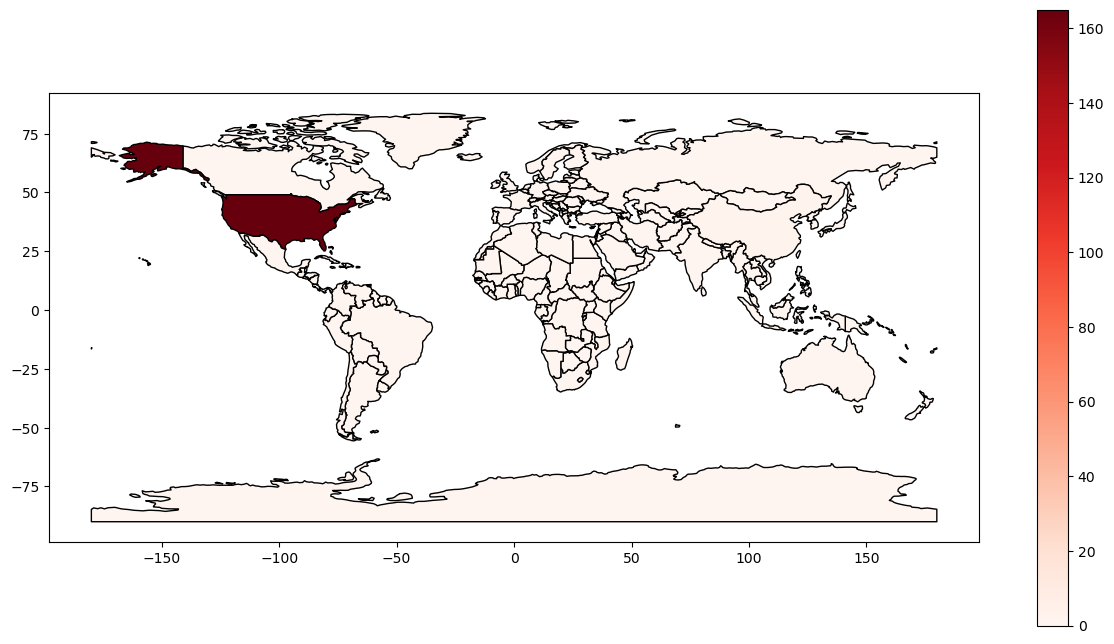

In [171]:
world_eq.plot(
    column="count",
    cmap="Reds",
    legend=True,
    figsize=(15,8),
    edgecolor="black"
)